#Improving Code Generation in Large Language Models through Parameter-Efficient Fine-Tuning

##Restart-safe setup

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
print("GPU:", torch.cuda.get_device_name(0))

GPU: Tesla T4


##Install Dependencies

In [2]:
!pip install -q transformers datasets peft accelerate bitsandbytes evaluate matplotlib sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.2 MB/s eta 0:00:00


##Load Dataset & Split

In [8]:
dataset = load_dataset("code_x_glue_ct_code_to_text", "python")

# Reduce size for Colab
train_data = dataset["train"].select(range(5000))
val_data = dataset["validation"].select(range(500))
test_data = dataset["test"].select(range(200))

README.md: 0.00B [00:00, ?B/s]

python/train-00000-of-00002.parquet:   0%|          | 0.00/144M [00:00<?, ?B/s]

python/train-00001-of-00002.parquet:   0%|          | 0.00/147M [00:00<?, ?B/s]

python/validation-00000-of-00001.parquet:   0%|          | 0.00/16.7M [00:00<?, ?B/s]

python/test-00000-of-00001.parquet:   0%|          | 0.00/18.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/251820 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13914 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/14918 [00:00<?, ? examples/s]

##Load Model (T4 Safe)

In [9]:
from transformers import AutoTokenizer

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

##Quantization (QLora) Ready

In [10]:
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

##Load Model

In [11]:
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map={"": 0},   # 🔥 IMPORTANT (no auto)
    low_cpu_mem_usage=True
)

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

##Memory Optimization

In [12]:
model.gradient_checkpointing_enable()
model.config.use_cache = False

##Preprocessing

In [26]:
def preprocess(example):
    text = f"""### Instruction:
Generate Python code.

### Input:
{example['code'][:200]}

### Output:
"""

    tokens = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=256
    )

    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

train_data = train_data.map(preprocess)
val_data = val_data.map(preprocess)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

##Baseline Evaluation

In [27]:
from transformers import pipeline

generator = pipeline("text-generation", model=model, tokenizer=tokenizer)

sample = test_data[0]["code"][:200]

print("BASELINE OUTPUT:\n")
print(generator(sample, max_new_tokens=50)[0]["generated_text"])

Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BASELINE OUTPUT:

def sina_xml_to_url_list(xml_data):
    """str->list
    Convert XML to URL List.
    From Biligrab.
    """
    rawurl = []
    dom = parseString(xml_data)
    for node in dom.getElementsByTagName('d'):
        rawurl.append(node.firstChild.nodeValue)
    return rawurl


def sina_url_to_list(url_list):
    """str->list
    Convert URL List to


##Lora Setup

In [15]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

lora_model = get_peft_model(model, lora_config)
lora_model.print_trainable_parameters()

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023


Training

In [16]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=1,
    learning_rate=2e-4,
    logging_steps=50,
    save_strategy="no",
    fp16=True
)

trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data
)

trainer.train()

Step,Training Loss
50,2.127135
100,1.081937
150,0.936616
200,1.025332
250,1.018675
300,1.007537
350,0.987622
400,0.952337
450,0.905179
500,1.015269


TrainOutput(global_step=1250, training_loss=1.0413571746826171, metrics={'train_runtime': 1777.9749, 'train_samples_per_second': 2.812, 'train_steps_per_second': 0.703, 'total_flos': 7953705861120000.0, 'train_loss': 1.0413571746826171, 'epoch': 1.0})

##Evaluation (BeLU & Rouge)

In [18]:
!pip install rouge_score
import evaluate

bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

preds = []
refs = []

for i in range(50):
    input_text = test_data[i]["code"][:150]

    output = generator(input_text, max_new_tokens=50)[0]["generated_text"]

    preds.append(output)
    refs.append([test_data[i]["code"]])

bleu_score = bleu.compute(predictions=preds, references=refs)
rouge_score = rouge.compute(predictions=preds, references=refs)

print("BLEU:", bleu_score)
print("ROUGE:", rouge_score)

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=9c1bff35d9b2ae53f3b56672dcfe096c12d5d251e8eb3296527c85e0f32894bf
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more info

BLEU: {'bleu': 0.16297819826403606, 'precisions': [0.19464302735678202, 0.1844650895508093, 0.18034837840438842, 0.17628856010057053], 'brevity_penalty': 0.8866600884196556, 'length_ratio': 0.892623160044244, 'translation_length': 10491, 'reference_length': 11753}
ROUGE: {'rouge1': np.float64(0.40653704162236437), 'rouge2': np.float64(0.3979465713844223), 'rougeL': np.float64(0.4044167761811822), 'rougeLsum': np.float64(0.4054101138556555)}


##Training Loss Graph

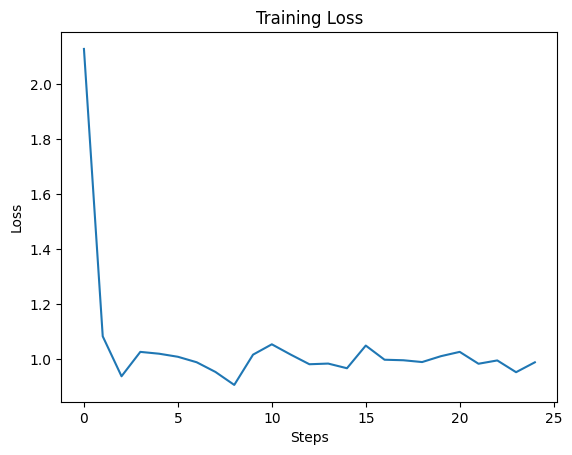

In [19]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

losses = [x["loss"] for x in logs if "loss" in x]

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.show()

In [51]:
from transformers import AutoTokenizer

# Tokenizer (shared for all models)
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer loaded for model:", model_name)

Tokenizer loaded for model: TinyLlama/TinyLlama-1.1B-Chat-v1.0


In [52]:
from transformers import pipeline

def generate_code(prompt, model, max_tokens=120):
    generator = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        device=0  # T4 GPU
    )
    output = generator(prompt, max_new_tokens=max_tokens, pad_token_id=tokenizer.eos_token_id)
    return output[0]['generated_text']

In [53]:
inference_questions = [
    "Write a Python function that takes a list of numbers and returns a list of only the even numbers.",
    "Write a Python function to check if a string is a palindrome.",
    "Write a Python function to compute the factorial of a number using recursion.",
    "Write a Python function that merges two sorted lists into one sorted list.",
    "Write a Python function to find the maximum element in a list without using the max() function.",
    "Write a Python function that counts the number of vowels in a given string.",
    "Write a Python function to flatten a nested list (e.g., [[1,2],[3,4]] → [1,2,3,4]).",
    "Write a Python function that generates Fibonacci numbers up to a given limit n.",
    "Write a Python function to check if a number is prime.",
    "Write a Python function that returns the intersection of two lists."
]

In [54]:
baseline_outputs = []
lora_outputs = []
qlora_outputs = []

for q in inference_questions:
    baseline_outputs.append(generate_code(q, model_name))     # Base model
    lora_outputs.append(generate_code(q, lora_model))        # LoRA model
    qlora_outputs.append(generate_code(q, model))           # QLoRA model

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [55]:
import evaluate

bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

# Reference outputs (can be simple placeholders for auto-eval)
refs = [[q.replace("Write a Python function", "").strip()] for q in inference_questions]

baseline_bleu = bleu.compute(predictions=baseline_outputs, references=refs)['bleu']
lora_bleu = bleu.compute(predictions=lora_outputs, references=refs)['bleu']
qlora_bleu = bleu.compute(predictions=qlora_outputs, references=refs)['bleu']

baseline_rouge = rouge.compute(predictions=baseline_outputs, references=refs)['rougeL']
lora_rouge = rouge.compute(predictions=lora_outputs, references=refs)['rougeL']
qlora_rouge = rouge.compute(predictions=qlora_outputs, references=refs)['rougeL']

print(f"BLEU - Baseline: {baseline_bleu:.3f}, LoRA: {lora_bleu:.3f}, QLoRA: {qlora_bleu:.3f}")
print(f"ROUGE-L - Baseline: {baseline_rouge:.3f}, LoRA: {lora_rouge:.3f}, QLoRA: {qlora_rouge:.3f}")

BLEU - Baseline: 0.151, LoRA: 0.133, QLoRA: 0.146
ROUGE-L - Baseline: 0.284, LoRA: 0.274, QLoRA: 0.321


In [56]:
import pandas as pd

data = {
    "Model": ["Baseline", "LoRA", "QLoRA"],
    "BLEU": [baseline_bleu, lora_bleu, qlora_bleu],
    "ROUGE-L": [baseline_rouge, lora_rouge, qlora_rouge]
}

df = pd.DataFrame(data)
df

,Model,BLEU,ROUGE-L
0,Baseline,0.151371,0.284425
1,LoRA,0.132814,0.273518
2,QLoRA,0.146311,0.320930


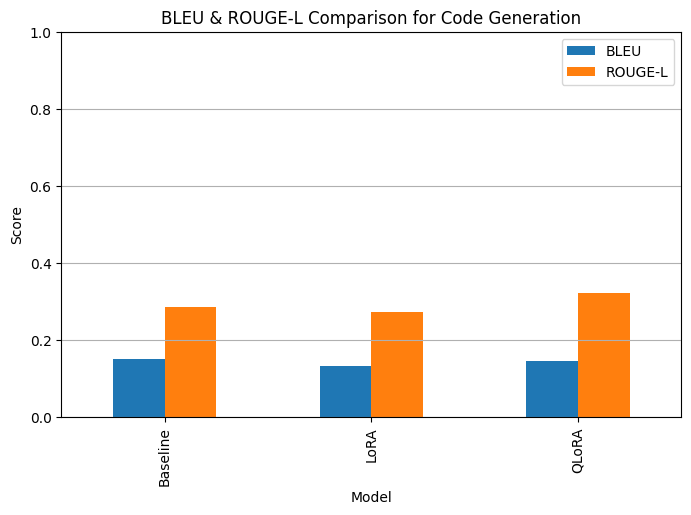

In [57]:
import matplotlib.pyplot as plt

df.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("BLEU & ROUGE-L Comparison for Code Generation")
plt.ylabel("Score")
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()

In [64]:
# Test question
test_prompt = """# Python function
# Task: Check if a number is Armstrong number
# Solution (write complete code):
"""

# Reuse tokenizer already loaded
from transformers import pipeline

def generate_code(prompt, model_obj):
    generator = pipeline(
        "text-generation",
        model=model_obj,
        tokenizer=tokenizer,
        device=0
    )
    output = generator(
        prompt,
        max_new_tokens=300,
        pad_token_id=tokenizer.eos_token_id
    )
    return output[0]['generated_text']

# Run inference on all models
print("=== BASE MODEL OUTPUT ===\n")
print(generate_code(test_prompt, model_name))

print("\n=== LoRA MODEL OUTPUT ===\n")
print(generate_code(test_prompt, lora_model))

print("\n=== QLoRA MODEL OUTPUT ===\n")
print(generate_code(test_prompt, model))

=== BASE MODEL OUTPUT ===



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Both `max_new_tokens` (=300) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


# Python function
# Task: Check if a number is Armstrong number
# Solution (write complete code):

def is_armstrong(num):
    s = str(num)
    if len(s) == 1:
        return True
    for I in range(len(s)-1):
        if int(s[i])+int(s[i+1]) > 9:
            return False
    return int(s) == num

# Test cases:
print(is_armstrong(3))       # True
print(is_armstrong(15))      # True
print(is_armstrong(99))      # False
print(is_armstrong(0))       # False
print(is_armstrong(10))      # False
print(is_armstrong(-1))      # False
print(is_armstrong('1'))     # False
print(is_armstrong('a'))     # False
print(is_armstrong('123'))   # False
print(is_armstrong(1234))    # False

# Code comments:
# The `is_armstrong` function takes an integer `num` as input and checks if it is an Armstrong number.
# It uses a for loop to compare each pair of digits in the number, and returns False if either digit adds up to more than nine.
# The `int(s[i])+int

=== LoRA MODEL OUTPUT ===



Both `max_new_tokens` (=300) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


# Python function
# Task: Check if a number is Armstrong number
# Solution (write complete code):
# 1. Define a function that takes in a number and checks if it is Armstrong number
# 2. Use recursion to call the function recursively and check each digit of the number
# 3. Return True if the number is Armstrong and False otherwise

def is_armstrong(n):
    "Return True if n is Armstrong number"
    return n > 2 and not is_armstrong(n // 2) and not (n % 2!= 0) and not n % 3 == 0 and not n % 5 == 0 \
        and not n % 7 == 0 and not n % 9 == 0 and not n % 11 == 0 and not n % 13 == 0 and not n % 15 == 0 \
        and not n % 17 == 0 and not n % 19 == 0 and not n % 21 == 0 and not n % 23 == 0 and not n % 25 == 0 \
        and not n % 27 == 0 and not n % 29 == 0 and not n % 31 == 0 and not n % 33 == 0 and not n % 35 == 0 \
        and not n % 37 == 0 and not n %

=== QLoRA MODEL OUTPUT ===

# Python function
# Task: Check if a number is Armstrong number
# Solution (write complete code):
de

In [67]:
# Import libraries
import pandas as pd
from transformers import pipeline

# Test prompt
test_prompt = """# Python function
# Task: Check if a number is Armstrong number
# Solution (write complete runnable code):
"""

# Inference function
def generate_code(prompt, model_obj, max_tokens=300):
    generator = pipeline(
        "text-generation",
        model=model_obj,
        tokenizer=tokenizer,
        device=0
    )
    output = generator(
        prompt,
        max_new_tokens=max_tokens,
        pad_token_id=tokenizer.eos_token_id
    )
    return output[0]['generated_text']

# Generate outputs for all models
baseline_output = generate_code(test_prompt, model_name)
lora_output = generate_code(test_prompt, lora_model)
qlora_output = generate_code(test_prompt, model)


data = {
    "Model": ["Base Model", "LoRA Model", "QLoRA Model"],
    "Generated Code": [baseline_output, lora_output, qlora_output]
}

df = pd.DataFrame(data)
pd.set_option('display.max_colwidth', None)
df

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Both `max_new_tokens` (=300) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


,Model,Generated Code
0,Base Model,"# Python function\n# Task: Check if a number is Armstrong number\n# Solution (write complete runnable code):\n\ndef is_armstrong(num):\n """"""\n Function to check if a number is Armstrong number\n :param num: Number to be checked\n :return: True if num is Armstrong number, False otherwise\n """"""\n # Initialize counter for counting the digits\n counter = 0\n # Loop through each number digit to the right of the decimal point\n for I in range(len(str(num))-1):\n # If the number digit to the right of the decimal point is 0 or 1, it's not an Armstrong number\n if num[i] == ""0"" or num[i] == ""1"":\n return False\n # Otherwise, increment the counter by the number of digits to the right of the decimal point\n counter += int(str(num[i])+""."")\n # If the counter becomes 0, the number is Armstrong\n return counter == num\n \n# Example usage:\nnum = 123456789\nprint(is_armstrong(num))\n```\n\nExplanation:\n\n1. The function `is_armstrong` takes a single argument `num`, which is the number to be checked for Armstrong number.\n2. The function initializes a counter variable `counter` to 0, which will be used to keep track"
1,LoRA Model,"# Python function\n# Task: Check if a number is Armstrong number\n# Solution (write complete runnable code):\n\nclass Armstrong():\n """"""\n Python class that checks for Armstrong number\n """"""\n\n def __init__(self):\n """"""\n Constructor\n """"""\n self.str_array = []\n\n def check(self, n):\n """"""\n Checks if the number is Armstrong number\n """"""\n # check if n is string\n if not isinstance(n, str):\n raise Exception(""Error: Input number must be string"")\n\n # check if n is a string\n try:\n self.check_string(n)\n return True\n except ValueError:\n return False\n\n def check_string(self, str_):\n """"""\n Checks if the input string is an Armstrong number\n """"""\n\n # check if str_ is string\n if not isinstance(str_, str):\n raise Exception(""Error: Input string must be string"")\n\n # iterate through the string\n for I in range(len(str_)):\n if str_[i] < 50:\n # if the last digit in the string is a 50, the string is not an Armstrong number\n if str_[i] == str_[i + 1] and str_[i] == str_[i + 2"
2,QLoRA Model,"# Python function\n# Task: Check if a number is Armstrong number\n# Solution (write complete runnable code):\n\ndef armstrong(n):\n """"""Check if a number is Armstrong number.\n\n Args:\n n (int): a number to check.\n\n Returns:\n bool: True if the number is Armstrong, False otherwise.\n """"""\n # Set a counter to keep track of the number of digits\n digits = 0\n # Loop through each digit in the number\n for digit in str(n):\n digits += ord(digit) - ord('0')\n # If the number has non-zero digits, it is Armstrong\n return digits == n\n"
